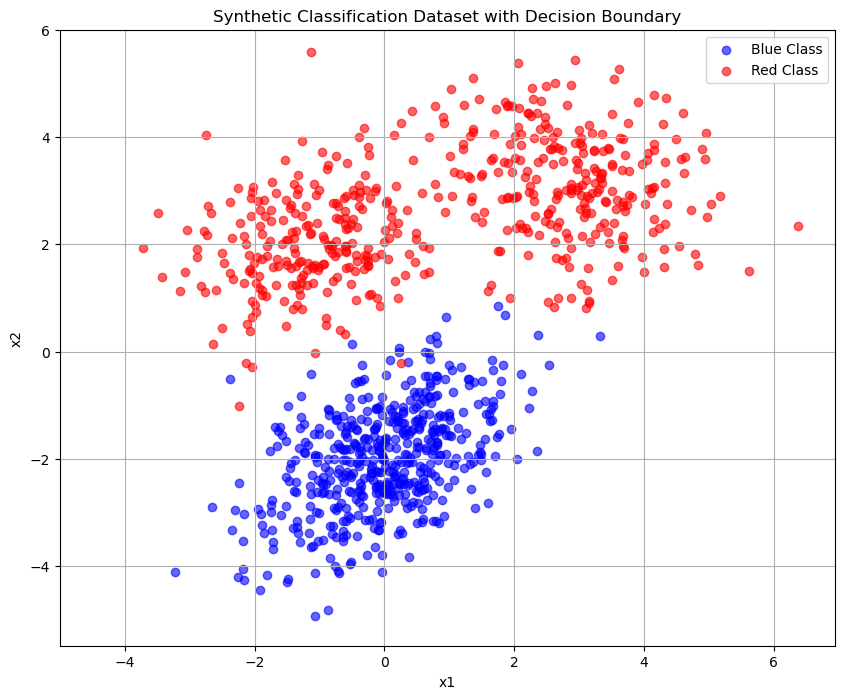

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Set random seed for reproducibility
np.random.seed(42)

# Blue class (single Gaussian)
mean_blue = np.array([0, -2])
cov_blue = np.array([[1, 0.5], [0.5, 1]])
n_samples = 500
X_blue = np.random.multivariate_normal(mean_blue, cov_blue, n_samples)

# Red class (mixture of two Gaussians)
mean_red1 = np.array([3, 3])
cov_red1 = np.array([[1, -0.3], [-0.3, 1]])

mean_red2 = np.array([-1, 2])
cov_red2 = np.array([[1, 0.3], [0.3, 1]])

n_samples_red = n_samples // 2
X_red1 = np.random.multivariate_normal(mean_red1, cov_red1, n_samples_red)
X_red2 = np.random.multivariate_normal(mean_red2, cov_red2, n_samples - n_samples_red)
X_red = np.vstack((X_red1, X_red2))

# Stack the full dataset
X = np.vstack((X_blue, X_red))
y = np.array([0]*n_samples + [1]*n_samples)  # 0 = blue, 1 = red

# Define the densities
pdf_blue = multivariate_normal(mean=mean_blue, cov=cov_blue)
pdf_red1 = multivariate_normal(mean=mean_red1, cov=cov_red1)
pdf_red2 = multivariate_normal(mean=mean_red2, cov=cov_red2)

def p_x_given_red(x):
    return 0.5 * pdf_red1.pdf(x) + 0.5 * pdf_red2.pdf(x)

# Grid for plotting
grid_size = 200
x = np.linspace(-5, 5, grid_size)
y_ = np.linspace(-1, 6, grid_size)
xx, yy = np.meshgrid(x, y_)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Compute class-conditional densities
p_blue = pdf_blue.pdf(grid_points)
p_red = p_x_given_red(grid_points)

# Priors (equal)
prior_blue = 0.5
prior_red = 0.5

# Posterior probabilities
posterior_blue = p_blue * prior_blue
posterior_red = p_red * prior_red
posterior_total = posterior_blue + posterior_red

post_blue = posterior_blue / posterior_total
post_red = posterior_red / posterior_total

# Decision boundary (where posterior_blue == posterior_red)
decision_boundary = np.abs(post_blue - post_red).reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 8))
plt.contour(xx, yy, decision_boundary, levels=[0], colors='k', linewidths=2)
plt.scatter(X_blue[:, 0], X_blue[:, 1], color='blue', label='Blue Class', alpha=0.6)
plt.scatter(X_red[:, 0], X_red[:, 1], color='red', label='Red Class', alpha=0.6)
plt.legend()
plt.title('Synthetic Classification Dataset with Decision Boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()


Linear regression may be unfit for classification, since outliers may bring too up (or too down) the fitted line, yielding possible misclassifications.

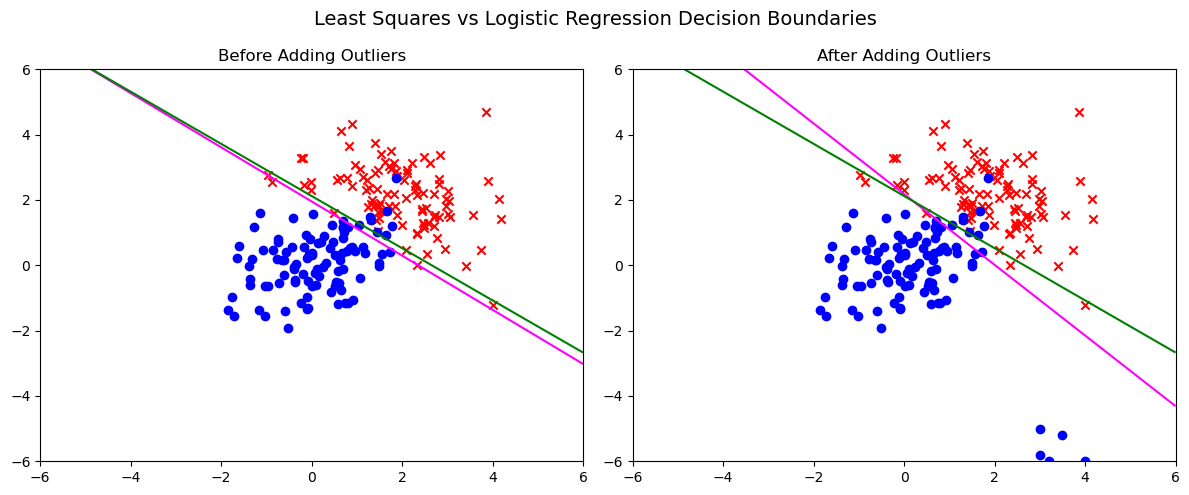

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

# Create base dataset
np.random.seed(42)

# Blue class
mean_blue = [0, 0]
cov_blue = [[1, 0.5], [0.5, 1]]
X_blue = np.random.multivariate_normal(mean_blue, cov_blue, 100)
y_blue = np.zeros(X_blue.shape[0])

# Red class
mean_red1 = [2, 2]
cov_red1 = [[1, -0.3], [-0.3, 1]]
X_red = np.random.multivariate_normal(mean_red1, cov_red1, 100)
y_red = np.ones(X_red.shape[0])

# Combine
X = np.vstack((X_blue, X_red))
y = np.hstack((y_blue, y_red))

# Create grid
xx, yy = np.meshgrid(np.linspace(-6, 6, 300), np.linspace(-6, 6, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Models before outliers
lr_ls = LinearRegression()
lr_log = LogisticRegression()

lr_ls.fit(X, y)
lr_log.fit(X, y)

# Predictions
zz_ls = lr_ls.predict(grid).reshape(xx.shape)
zz_log = lr_log.predict_proba(grid)[:, 1].reshape(xx.shape)

# Plot BEFORE outliers
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contour(xx, yy, zz_ls, levels=[0.5], colors='magenta')
plt.contour(xx, yy, zz_log, levels=[0.5], colors='green')
plt.scatter(X_red[:, 0], X_red[:, 1], marker='x', color='red')
plt.scatter(X_blue[:, 0], X_blue[:, 1], marker='o', color='blue')
plt.title("Before Adding Outliers")
plt.ylim(-6,6)
plt.xlim(-6,6)

# === Add outliers ===
outliers_blue = np.array([
    [3, -5],
    [3.5, -5.2],
    [3, -5.8],
    [3.2, -6],
    [4, -6]
])
X_with_outliers = np.vstack([X, outliers_blue])
y_with_outliers = np.hstack([y, np.zeros(len(outliers_blue))])  # Blue class

# Retrain with outliers
lr_ls.fit(X_with_outliers, y_with_outliers)
lr_log.fit(X_with_outliers, y_with_outliers)

# Predictions
zz_ls = lr_ls.predict(grid).reshape(xx.shape)
zz_log = lr_log.predict_proba(grid)[:, 1].reshape(xx.shape)

# Plot AFTER outliers
plt.subplot(1, 2, 2)
plt.contour(xx, yy, zz_ls, levels=[0.5], colors='magenta')
plt.contour(xx, yy, zz_log, levels=[0.5], colors='green')
plt.scatter(X_red[:, 0], X_red[:, 1], marker='x', color='red')
plt.scatter(X_blue[:, 0], X_blue[:, 1], marker='o', color='blue')
plt.scatter(outliers_blue[:, 0], outliers_blue[:, 1], marker='o', color = 'blue')
plt.title("After Adding Outliers")
plt.ylim(-6,6)
plt.xlim(-6,6)

plt.suptitle("Least Squares vs Logistic Regression Decision Boundaries", fontsize=14)
plt.tight_layout()
plt.show()


Better results in terms of classifications rate can be achieved when one uses other (famous) models, for example the Linear Discriminant Analysis (LDA) and Logistic regression. In the following example, we consider fitting a classical OLS against a Logistic regression when we have 3 classes instead of 2.

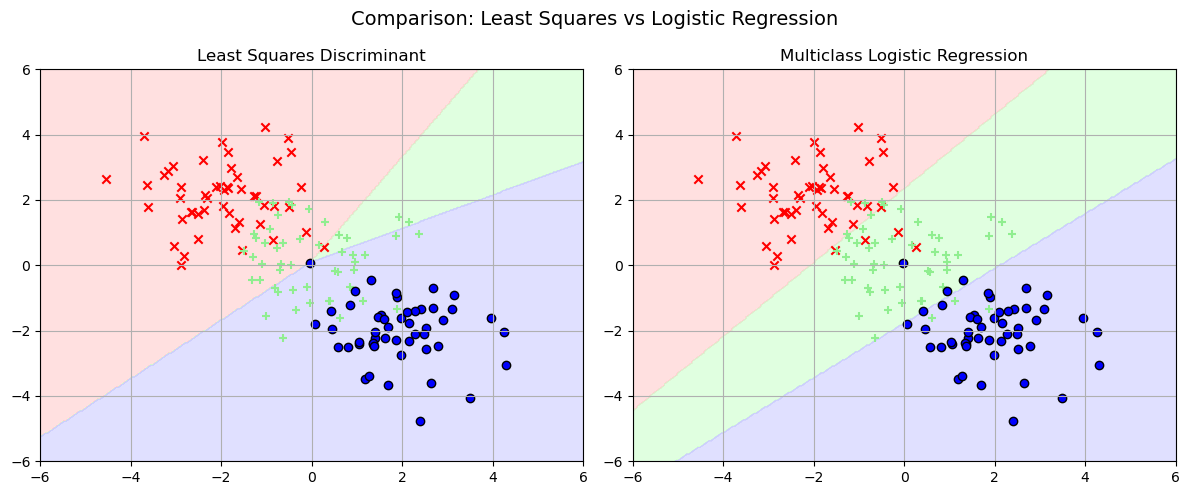

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from matplotlib.colors import ListedColormap

# Set seed for reproducibility
np.random.seed(0)

# Class 0 (Red X)
X0 = np.random.multivariate_normal(mean=[-2, 2], cov=[[1, 0], [0, 1]], size=50)
y0 = np.zeros(len(X0), dtype=int)

# Class 1 (Green +)
X1 = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=50)
y1 = np.ones(len(X1), dtype=int)

# Class 2 (Blue O)
X2 = np.random.multivariate_normal(mean=[2, -2], cov=[[1, 0], [0, 1]], size=50)
y2 = np.full(len(X2), 2)

# Stack the data
X = np.vstack((X0, X1, X2))
y = np.concatenate((y0, y1, y2))

# One-hot encode labels for Least Squares
encoder = OneHotEncoder(sparse_output=False)
Y_onehot = encoder.fit_transform(y.reshape(-1, 1))

# Add bias term for least squares
X_aug = np.hstack((np.ones((X.shape[0], 1)), X))  # Shape: (N, 3)

# Solve using pseudo-inverse: W = (X^T X)^(-1) X^T Y
W_ls = np.linalg.pinv(X_aug) @ Y_onehot

# Prediction function for least squares
def predict_ls(X_query):
    Xq_aug = np.hstack((np.ones((X_query.shape[0], 1)), X_query))
    scores = Xq_aug @ W_ls
    return np.argmax(scores, axis=1)

# Logistic Regression classifier
clf_logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs')
clf_logreg.fit(X, y)

# Grid for decision boundaries
xx, yy = np.meshgrid(np.linspace(-6, 6, 300), np.linspace(-6, 6, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_ls = predict_ls(grid).reshape(xx.shape)
Z_log = clf_logreg.predict(grid).reshape(xx.shape)

# Colormap for class regions
cmap_bg = ListedColormap(['#FFCCCC', '#CCFFCC', '#CCCCFF'])  # light red, green, blue

# Plot
plt.figure(figsize=(12, 5))

# Left plot: Least Squares
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_ls, cmap=cmap_bg, alpha=0.6)
plt.scatter(X0[:, 0], X0[:, 1], c='red', marker='x', label='Class 0')
plt.scatter(X1[:, 0], X1[:, 1], c='lightgreen', marker='+', label='Class 1')
plt.scatter(X2[:, 0], X2[:, 1], c='blue', marker='o', edgecolors='black', label='Class 2')
plt.title('Least Squares Discriminant')
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.grid(True)

# Right plot: Logistic Regression
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_log, cmap=cmap_bg, alpha=0.6)
plt.scatter(X0[:, 0], X0[:, 1], c='red', marker='x', label='Class 0')
plt.scatter(X1[:, 0], X1[:, 1], c='lightgreen', marker='+', label='Class 1')
plt.scatter(X2[:, 0], X2[:, 1], c='blue', marker='o', edgecolors='black', label='Class 2')
plt.title('Multiclass Logistic Regression')
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.grid(True)

plt.suptitle("Comparison: Least Squares vs Logistic Regression", fontsize=14)
plt.tight_layout()
plt.show()


The Laplace approximation is a deterministic method that aims to find a Gaussian approximation to a probability density defined over a set of continuous variables. In the following example we will consider as target distribution
$$ p(z) \propto \sigma(20z + 4) \exp(-z^2/2)$$
The Laplace approximation is based on a second-order Taylor expansion to obtain a quadratic term, which is exploited to recognize the kernel of a Gaussian distribution,
$$ q(\mathbf{z}) = \frac{\vert \mathbf{A} \vert^{1/2}}{(2\pi)^{M/2}} \exp\left( -\frac{1}{2}(\mathbf{z}-\mathbf{z}_0)^\top \mathbf{A}(\mathbf{z}-\mathbf{z}_0) \right) = \mathcal{N} (\mathbf{z}\mid \mathbf{z}_0, \mathbf{A}^{-1})$$
where $\mathbf{z}_0$ is a local maximum (usually the MLE or the MAP) and $\mathbf{A} = - \nabla^2 \ln f(\mathbf{z}) \vert_{\mathbf{z} = \mathbf{z}_0}$ is the negative Hessian.

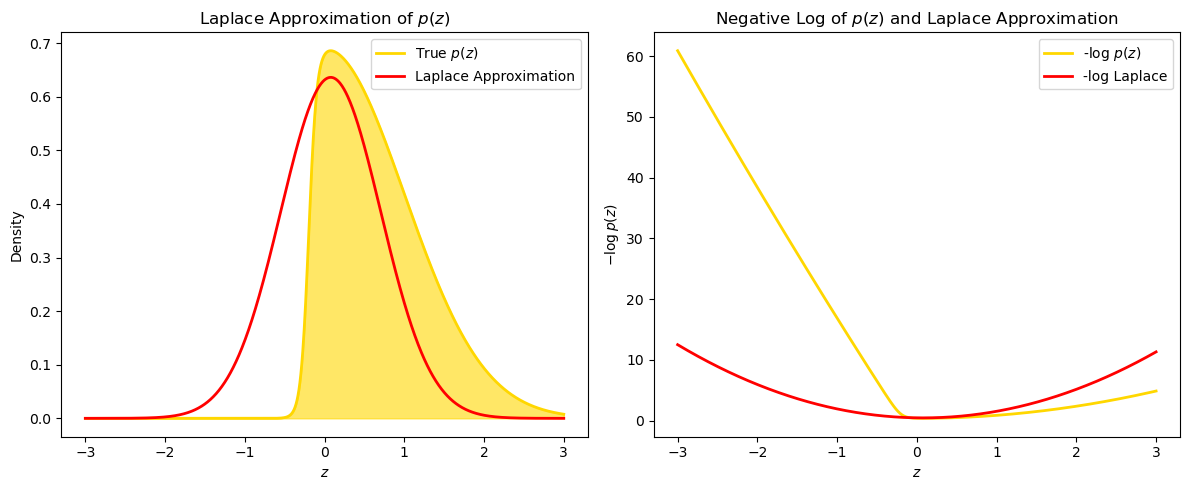

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit  # sigmoid
from scipy.optimize import minimize_scalar
from scipy.stats import norm

# Define unnormalized log p(z)
def log_p(z):
    return -0.5 * z**2 + np.log(expit(20*z + 4))

# First and second derivatives for Laplace approx
def d2_log_p(z):
    sig = expit(20*z + 4)
    return -1 - (20**2) * sig * (1 - sig)

# Find the mode z0 by maximizing log p(z)
res = minimize_scalar(lambda z: -log_p(z), bounds=(-3, 3), method='bounded')
z0 = res.x
log_p_z0 = log_p(z0)

# Second derivative at mode → variance = -1 / second derivative
second_deriv = d2_log_p(z0)
sigma2 = -1 / second_deriv
sigma = np.sqrt(sigma2)

# Define Laplace approximation: Gaussian N(z0, sigma^2)
def laplace_approx(z):
    return norm.pdf(z, loc=z0, scale=sigma)

# Evaluate p(z) and Laplace approx on grid
z = np.linspace(-3, 3, 1000)
p_unnorm = np.exp(log_p(z))
p_norm = p_unnorm / np.trapz(p_unnorm, z)  # normalize numerically

laplace = laplace_approx(z)

# Plotting
plt.figure(figsize=(12, 5))

# Left: p(z) and Laplace approximation
plt.subplot(1, 2, 1)
plt.plot(z, p_norm, label='True $p(z)$', color='gold', linewidth=2)
plt.fill_between(z, p_norm, color='gold', alpha=0.6)
plt.plot(z, laplace, label='Laplace Approximation', color='red', linewidth=2)
plt.title('Laplace Approximation of $p(z)$')
plt.xlabel('$z$')
plt.ylabel('Density')
plt.legend()

# Right: Negative log plots
plt.subplot(1, 2, 2)
plt.plot(z, -np.log(p_norm), label='-log $p(z)$', color='gold', linewidth=2)
plt.plot(z, -np.log(laplace), label='-log Laplace', color='red', linewidth=2)
plt.title('Negative Log of $p(z)$ and Laplace Approximation')
plt.xlabel('$z$')
plt.ylabel('$-\\log p(z)$')
plt.legend()

plt.tight_layout()
plt.show()
